In [2]:
import scanpy as sc
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import KernelDensity
import os

# Set default figure size
plt.rcParams['figure.figsize'] = (12, 6)
PT_SIZE = 90
SAVE_MATRIX = True

In [3]:
adata = sc.read_h5ad("/home/lemgui01/SIGMA/data/results_mk_12_noMONO/find/Isola_nature_10-1038_s43587-023-00552-5.h5ad")

In [11]:
adata.obs

,orig.ident,nCount_RNA,nFeature_RNA,percent.mito,percent_ribo,percent_hb,percent_plat,age,S.Score,G2M.Score,...,pct_counts_hb,outlier,mt_outlier,doublet_score,doublet_class,marker_mean_expr,exclude_mean_expr,proba_target,proba_exclu,score
1_CATGCCTTCTCCGAGG-1,1,578.757087,502,0.015407,8.929699,0.000000,0.000000,YOUNG,-0.078729,0.076567,...,0.000000,False,False,0.041987,False,1.112460,0.000000,1.284799e-41,0.000193,-0.000193
1_CCGCAAGGTAGTTACC-1,1,1415.811053,1018,0.011677,11.746511,0.000000,0.000000,YOUNG,0.045205,-0.065169,...,0.000000,False,False,0.058500,False,0.970141,0.000000,2.056465e-54,0.000193,-0.000193
1_GACTCAAGTGATACAA-1,1,1315.639690,1027,0.015442,10.797090,0.000000,0.069548,YOUNG,0.050843,-0.076170,...,0.000000,False,False,0.047323,False,0.975643,0.464162,6.159393e-54,1.000000,-1.000000
1_GAGTCATCAAGACAAT-1,1,3432.542599,2246,0.044483,6.570076,0.000000,0.000000,YOUNG,-0.117163,-0.143661,...,0.000000,False,False,0.031135,False,0.941806,0.000000,7.642135e-57,0.000193,-0.000193
1_GGAGGTAAGACTGAGC-1,1,518.978483,449,0.002759,9.292694,0.000000,0.000000,YOUNG,0.078200,0.028039,...,0.000000,False,False,0.015198,False,1.097772,0.000000,5.529789e-43,0.000193,-0.000193
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8_CTAAGTGGTTCTGACA-1,8,1504.697963,1020,0.026336,8.043826,0.000000,0.000000,OLD,-0.114043,-0.021053,...,0.000000,False,False,0.006944,False,0.970215,0.522545,2.087266e-54,1.000000,-1.000000
8_GCAGCTGCACCTCGTT-1,8,517.391767,444,0.019349,8.246211,0.000000,0.000000,OLD,-0.082612,-0.099307,...,0.000000,False,False,0.079545,False,1.098493,0.000000,6.449958e-43,0.000193,-0.000193
8_GTTAGACTCTGAACGT-1,8,575.904414,514,0.020220,5.933022,0.000000,0.000000,OLD,-0.009030,-0.036719,...,0.000000,False,False,0.044056,False,1.078479,0.000000,9.207736e-45,0.000193,-0.000193
8_TCACTCGGTAGGTAGC-1,8,7720.667735,3631,0.015887,8.700131,0.011975,0.000000,OLD,-0.151271,-0.165750,...,0.020056,False,False,0.028018,False,0.884317,0.000000,1.183011e-61,0.000193,-0.000193


(array([16.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., 72.,  3.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  2.]),
 array([-1.00000000e+00, -9.80001926e-01, -9.60003851e-01, -9.40005777e-01,
        -9.20007703e-01, -9.00009628e-01, -8.80011554e-01, -8.60013479e-01,
        -8.40015405e-01, -8.20017331e-01, -8.00019256e-01, -7.80021182e-01,
        -7.60023108e-01, -7.40025033e-01, -7.20026959e-01, -7.00028885e-01,
        -6.80030810e-01, -6.60032736e-01, -6.40034661e-01, -6.20036587e-01,
        -6.00038513e-01, -5.80040438e-01, -5.60042364e

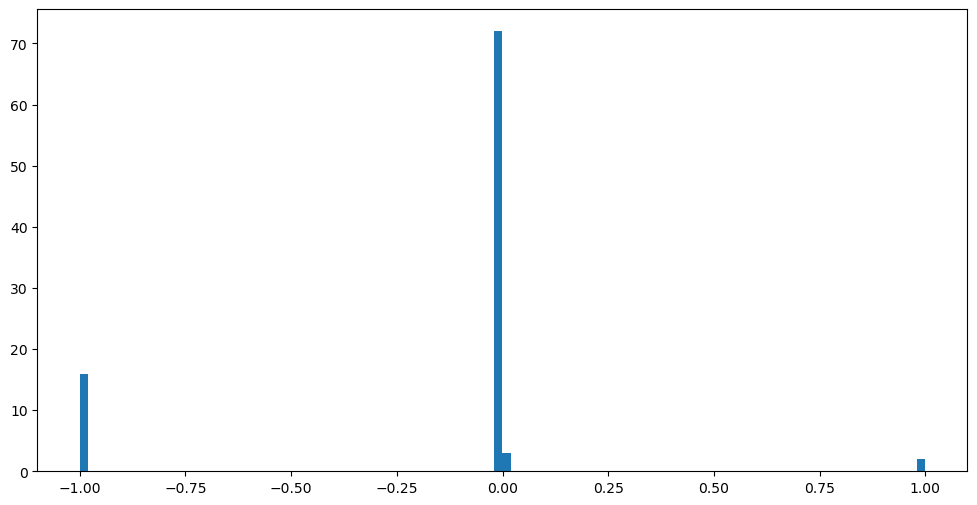

In [18]:
plt.hist(score, bins=100)

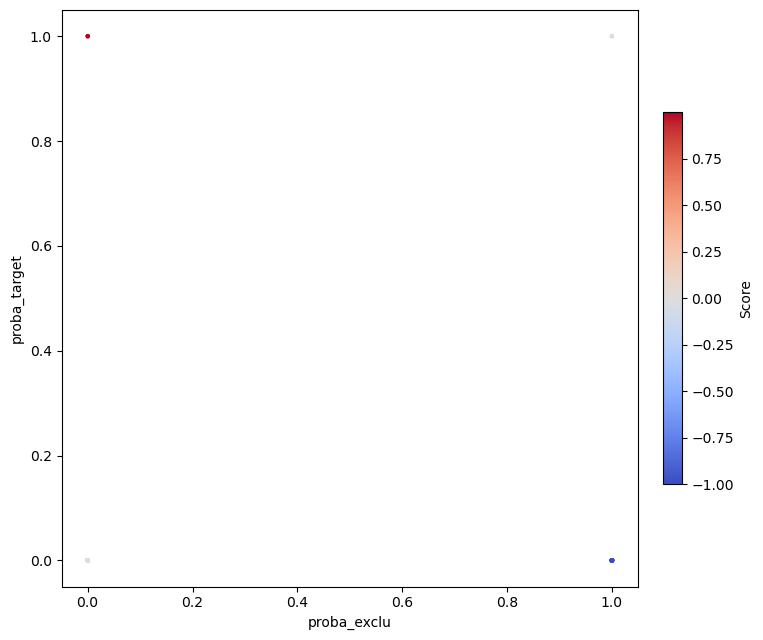

In [15]:
x = adata.obs['proba_exclu']
y = adata.obs['proba_target']
score = y - x

fig, ax = plt.subplots(figsize=(8, 8))
# scatter coloré par le score
sc = ax.scatter(x, y, c=score, cmap='coolwarm', s=5)

ax.set_box_aspect(1)
ax.set_xlabel('proba_exclu')
ax.set_ylabel('proba_target')

# légendes et barre de couleur
cbar = plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label('Score')

plt.show()

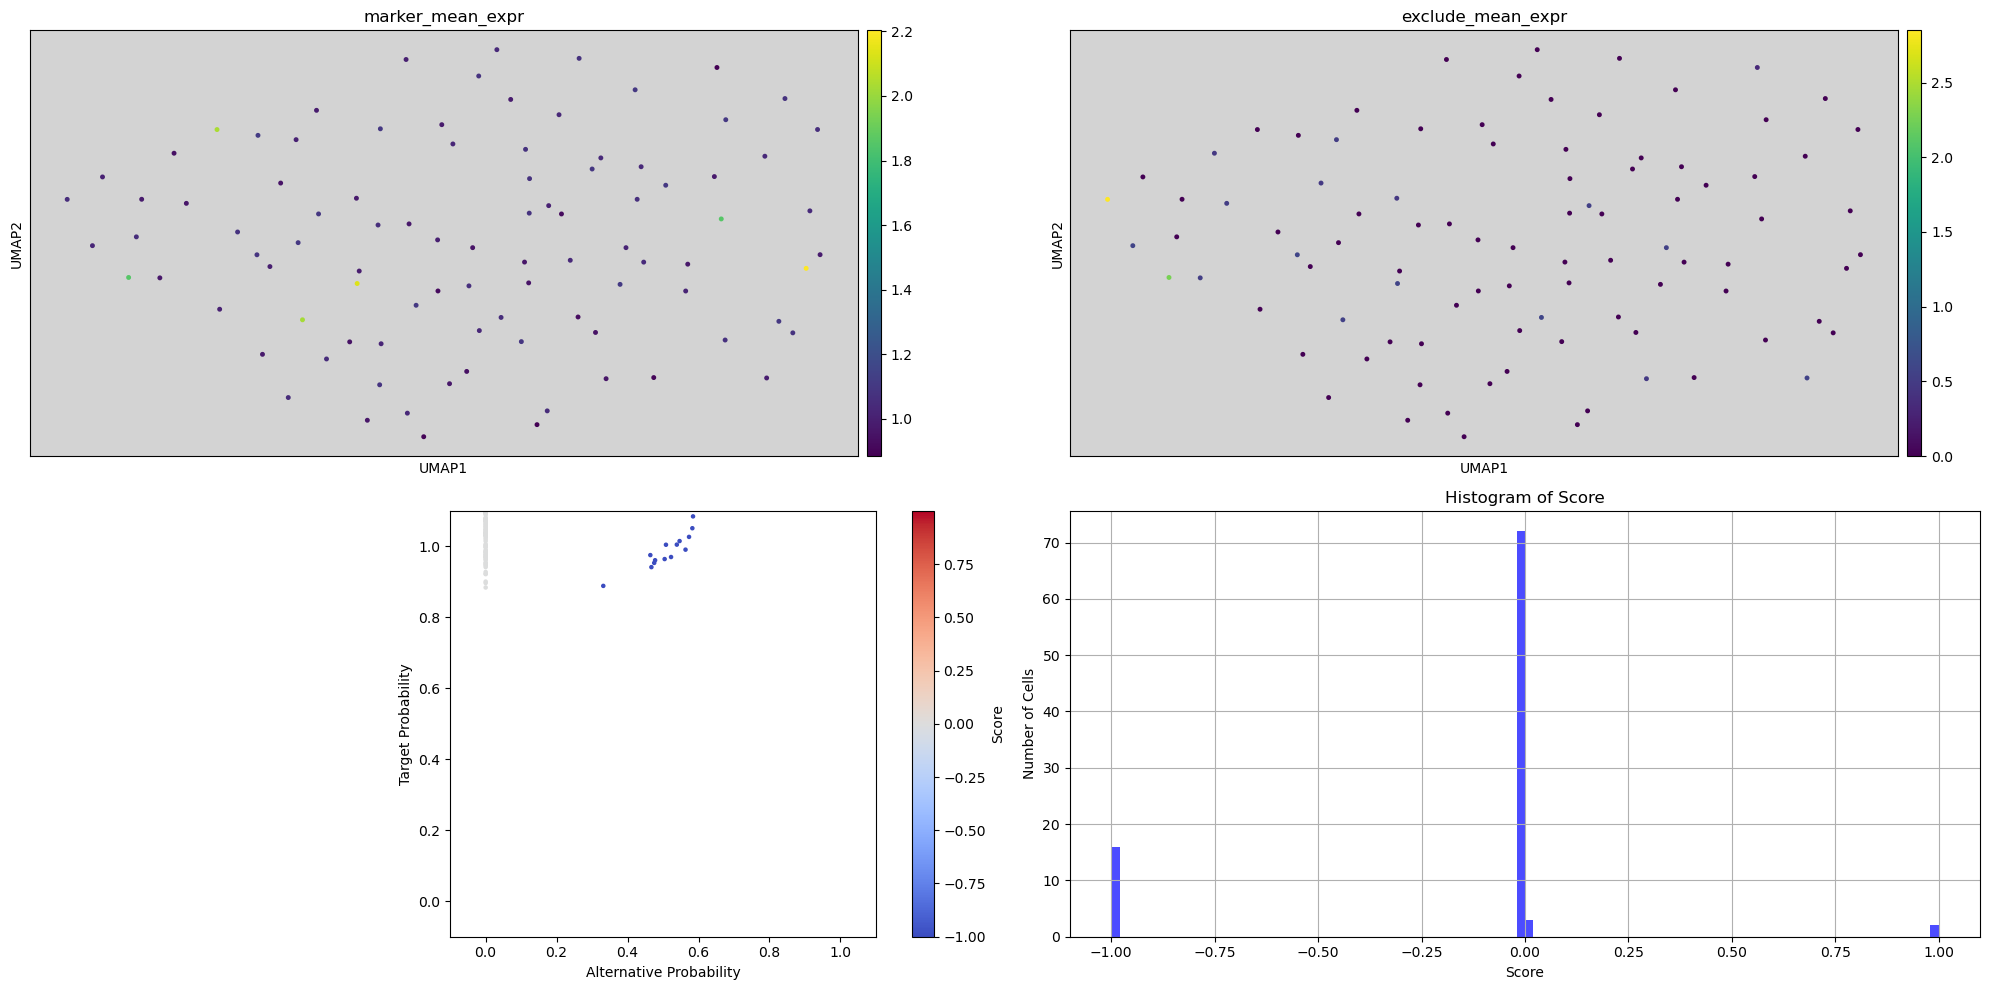

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(20, 10))

sc.pl.umap(adata, color="marker_mean_expr", cmap="viridis", ax=axes[0, 0], size=50, show=False)
sc.pl.umap(adata, color="exclude_mean_expr", cmap="viridis", ax=axes[0, 1], size=50, show=False)
axes[0, 0].set_facecolor('lightgrey')
axes[0, 1].set_facecolor('lightgrey')

x = adata.obs["exclude_mean_expr"]
y = adata.obs["marker_mean_expr"]
score = adata.obs["score"]
axes[1, 0].scatter(x, y, c=score, cmap='coolwarm', s=5)
axes[1, 0].set_xlabel("Alternative Probability")
axes[1, 0].set_ylabel("Target Probability")
axes[1, 0].set_xlim(-0.1, 1.1)
axes[1, 0].set_ylim(-0.1, 1.1)
axes[1, 0].set_box_aspect(1)

cbar = plt.colorbar(axes[1, 0].collections[0], ax=axes[1, 0], fraction=0.03, pad=0.04)
cbar.set_label("Score")
# Plot histogram of score
axes[1, 1].hist(adata.obs["score"], bins=100, color='blue', alpha=0.7)
axes[1, 1].set(title="Histogram of Score", xlabel="Score", ylabel="Number of Cells")
axes[1, 1].grid(True)

fig.tight_layout()